In [24]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# Análisis del flotador

## Extracción de datos en el dominio del tiempo

Los resultados se guardan en SeaFEM en ficheros .res, por lo que hay que adecuarlos al formato Pandas Dataframe.

In [52]:
path = rf'D:\arturo_sim\simulaciones\acoplado\analisis_1'
dataframes = {} #Almacen en formato diccionario para poder etiquetar los df de cada simulación con la regla establecida

In [62]:
for sea in range(1,4):

    # Abrimos y extraemos la información del archivo .res
    res_path = os.path.join(path,f'oc4_0_{sea}.gid',f'oc4_0_{sea}.BodyKinematics.res')
    with open(res_path,'rb') as res:
        res_data = res.read().decode('utf-8', errors='ignore')

    # Escribimos la información del .res en un .txt
    txt_path = os.path.join(path,'time_data',f'oc4_0_{sea}.txt')
    with open(txt_path, 'w', encoding='utf-8') as txt_file:
        txt_file.write(res_data)

    # Almaceno los resultados del número de simulaciones empleado
    dataframes[f'df_0_{sea}'] = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]


In [63]:
dataframes.keys()

dict_keys(['df_0_1', 'df_0_2', 'df_0_3'])

In [64]:
dataframes['df_0_2']

,time[s],Surge,Sway,Heave,Roll,Pitch,Yaw
0,300.0,-9.96291,0.758357,-2.40068,-0.003367,-0.083919,-0.000741
1,300.1,-9.92896,0.797260,-2.36098,-0.003321,-0.083921,-0.000277
2,300.2,-9.89388,0.835161,-2.32053,-0.003274,-0.083926,0.000225
3,300.3,-9.85775,0.871922,-2.27935,-0.003228,-0.083935,0.000763
4,300.4,-9.82065,0.907407,-2.23747,-0.003183,-0.083946,0.001332
...,...,...,...,...,...,...,...
8996,1199.6,-8.71738,0.598873,-2.91251,-0.004936,-0.083512,-0.001265
8997,1199.7,-8.74031,0.607176,-2.88581,-0.004987,-0.083371,-0.001442
8998,1199.8,-8.76455,0.615728,-2.85714,-0.005032,-0.083232,-0.001595
8999,1199.9,-8.78998,0.624536,-2.82650,-0.005073,-0.083098,-0.001725


Comparamos desplazamientos en los 6 DOF

In [79]:
for key, df in dataframes.items():
    print(key)
    print(df)

df_0_1
      time[s]    Surge      Sway    Heave      Roll     Pitch       Yaw
0       300.0 -8.78082  0.502942 -1.60837 -0.004012 -0.083812 -0.002283
1       300.1 -8.77779  0.522830 -1.60944 -0.003979 -0.083810 -0.001956
2       300.2 -8.77474  0.542187 -1.61063 -0.003945 -0.083811 -0.001587
3       300.3 -8.77170  0.560927 -1.61192 -0.003910 -0.083816 -0.001176
4       300.4 -8.76872  0.578969 -1.61330 -0.003873 -0.083823 -0.000727
...       ...      ...       ...      ...       ...       ...       ...
8996   1199.6 -8.04915  0.336193 -1.77823 -0.004842 -0.083993 -0.001406
8997   1199.7 -8.06923  0.329811 -1.78146 -0.004886 -0.083896 -0.001550
8998   1199.8 -8.09066  0.323850 -1.78418 -0.004926 -0.083800 -0.001672
8999   1199.9 -8.11336  0.318328 -1.78636 -0.004961 -0.083707 -0.001771
9000   1200.0 -8.13722  0.313253 -1.78798 -0.004992 -0.083615 -0.001850

[9001 rows x 7 columns]
df_0_2
      time[s]    Surge      Sway    Heave      Roll     Pitch       Yaw
0       300.0 -9.96291  0

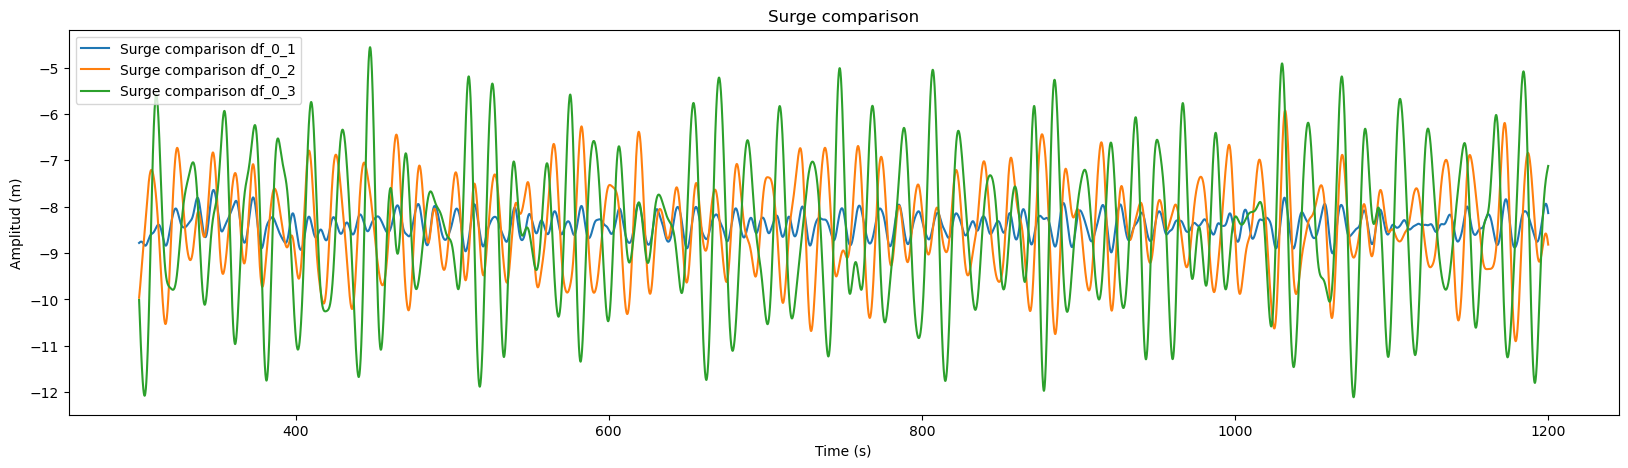

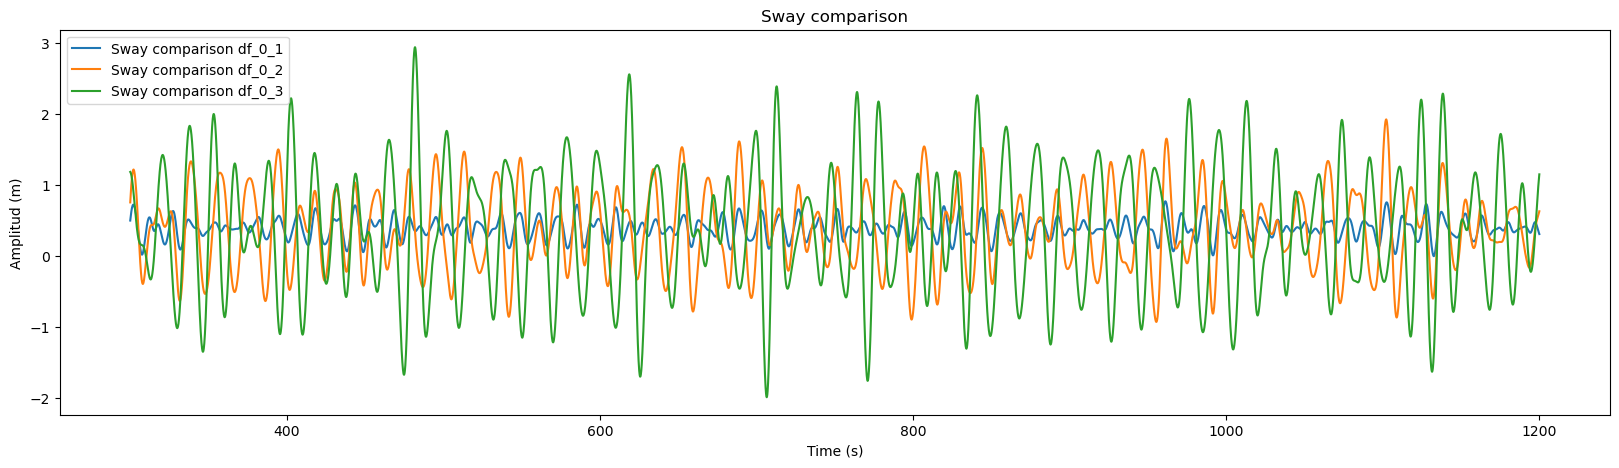

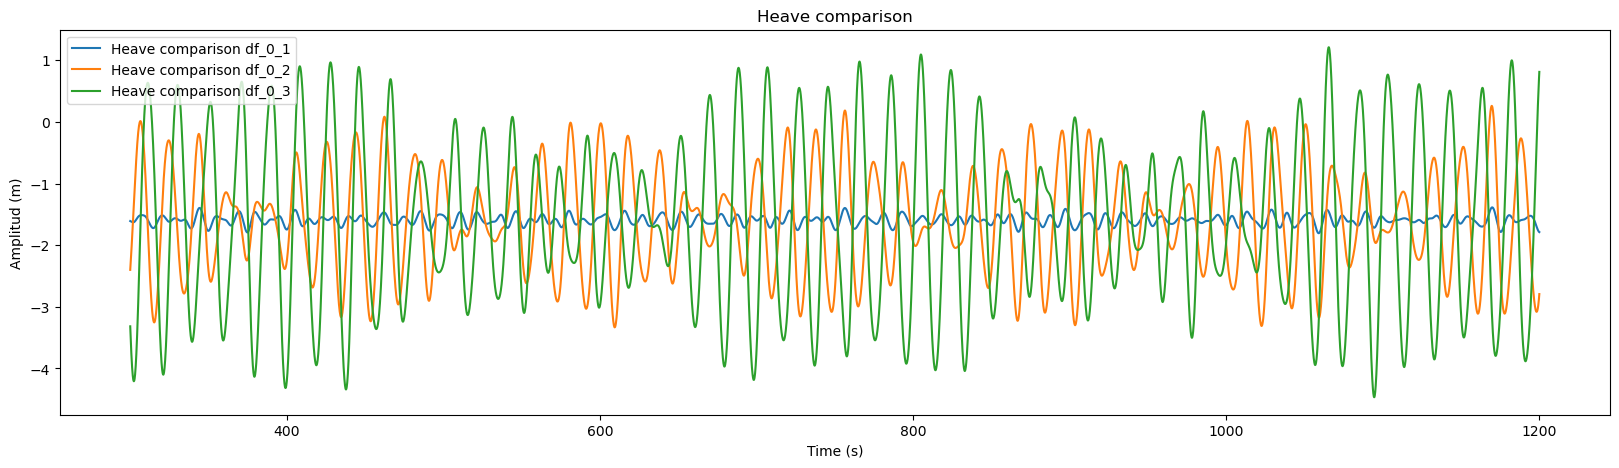

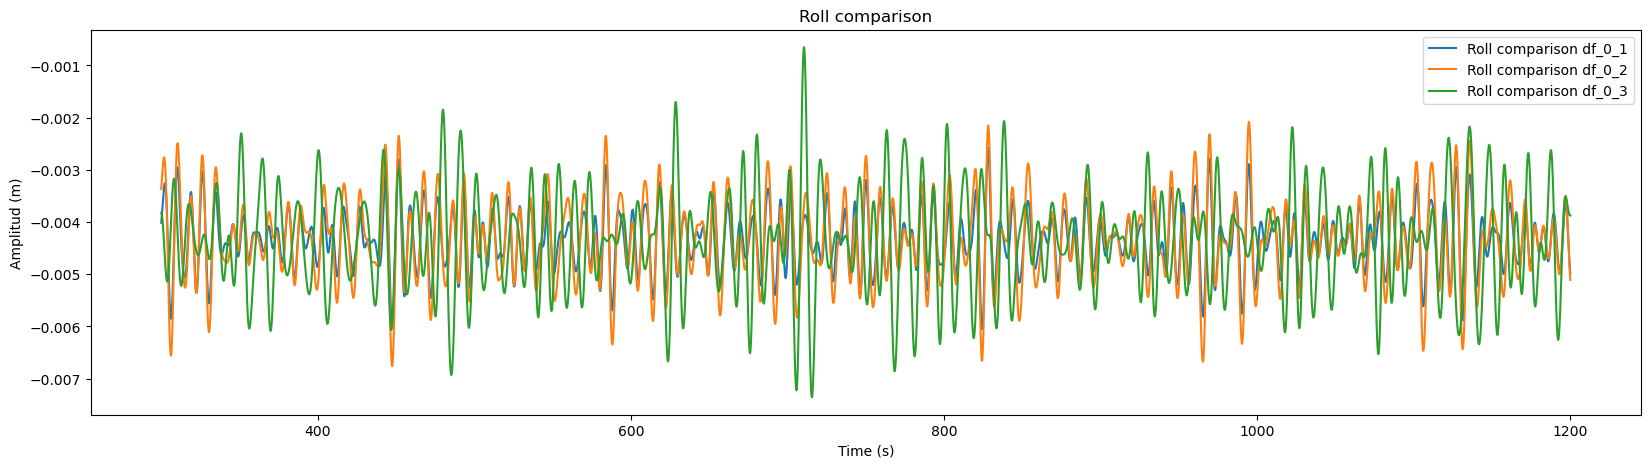

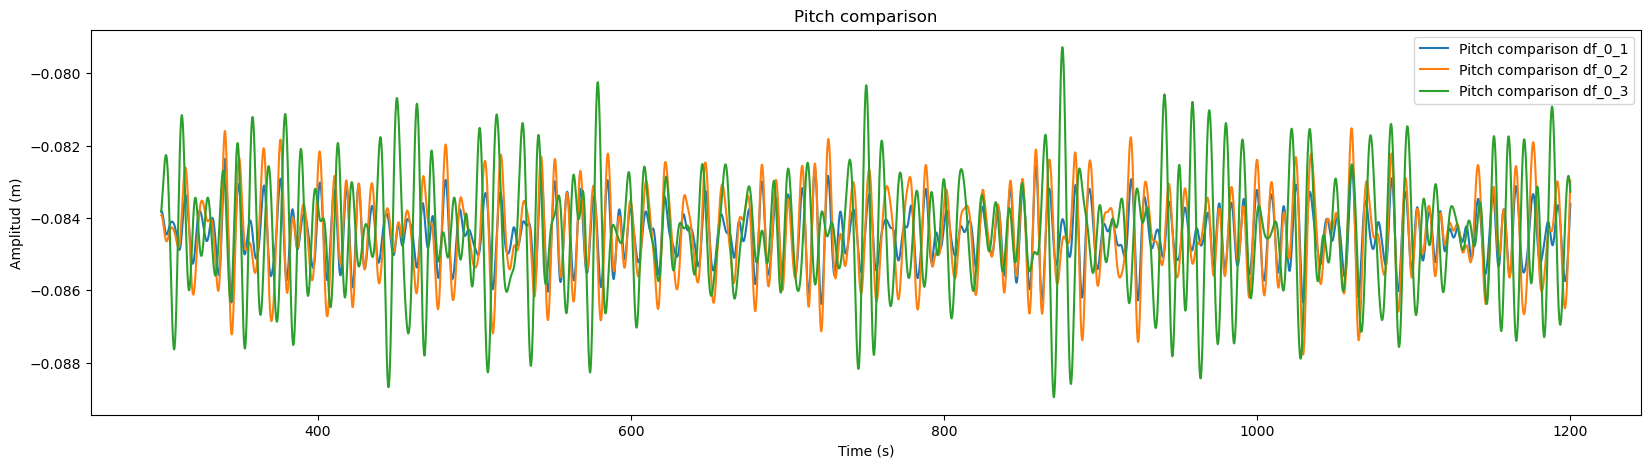

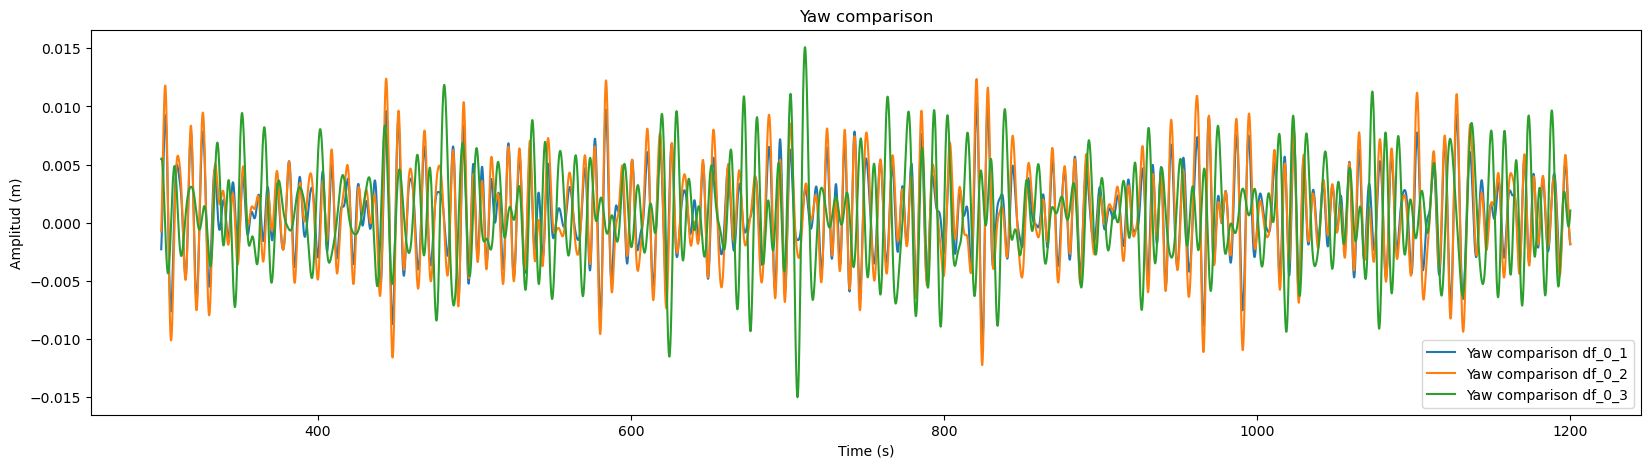

In [93]:
movements = ['Surge','Sway','Heave','Roll','Pitch','Yaw']
for mov in movements:
    plt.figure(figsize=(20, 5))

    for key, df in dataframes.items():
        if mov in df.columns:
            plt.plot(df['time[s]'],df[mov],label=f"{mov} comparison {key}")
            
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitud (m)')
    plt.title(f"{mov} comparison")
    plt.legend()
    plt.show()